In [1]:
import geopandas as gpd
import matplotlib.pyplot as plt

In [2]:
wrs_tiles = gpd.read_file("wrs2_tiles.gpkg")


# extract path & row
wrs_tiles[["WRS_PATH", "WRS_ROW"]] = wrs_tiles["Name"].str.split('_', expand=True)
wrs_tiles

,Name,Description,geometry,WRS_PATH,WRS_ROW
0,16_122,<!-- Format: CSV (generated by convert2vector ...,"POLYGON Z ((-178.785 -80.929 7000, -177.567 -8...",16,122
1,15_122,<!-- Format: CSV (generated by convert2vector ...,"POLYGON Z ((-177.24 -80.929 7000, -176.021 -82...",15,122
2,14_122,<!-- Format: CSV (generated by convert2vector ...,"POLYGON Z ((-175.695 -80.929 7000, -174.476 -8...",14,122
3,13_122,<!-- Format: CSV (generated by convert2vector ...,"POLYGON Z ((-174.15 -80.929 7000, -172.931 -82...",13,122
4,12_122,<!-- Format: CSV (generated by convert2vector ...,"POLYGON Z ((-172.605 -80.929 7000, -171.386 -8...",12,122
...,...,...,...,...,...
28552,124_247,<!-- Format: CSV (generated by convert2vector ...,"POLYGON Z ((171.759 82.696 7000, 172.726 80.94...",124,247
28553,123_247,<!-- Format: CSV (generated by convert2vector ...,"POLYGON Z ((173.304 82.696 7000, 174.271 80.94...",123,247
28554,122_247,<!-- Format: CSV (generated by convert2vector ...,"POLYGON Z ((174.85 82.696 7000, 175.816 80.942...",122,247
28555,121_247,<!-- Format: CSV (generated by convert2vector ...,"POLYGON Z ((176.395 82.696 7000, 177.361 80.94...",121,247


In [4]:
german_mask = gpd.read_file("de.json")
german_mask

,source,id,name,geometry
0,https://simplemaps.com,DE,Germany,"MULTIPOLYGON (((13.81572 48.76643, 13.78586 48..."


In [5]:
wrs_tiles = wrs_tiles.to_crs(epsg=3857)
german_mask = german_mask.to_crs(epsg=3857)

In [6]:
german_mask.crs == wrs_tiles.crs

True

In [7]:
wrs_tiles["orig_area"] = wrs_tiles.geometry.area

In [8]:
overlap = gpd.overlay(wrs_tiles, german_mask, how="intersection")

In [9]:
overlap["clipped_area"] = overlap.geometry.area

In [10]:
overlap["remaining_area"] = overlap["clipped_area"] / overlap["orig_area"]

<Axes: >

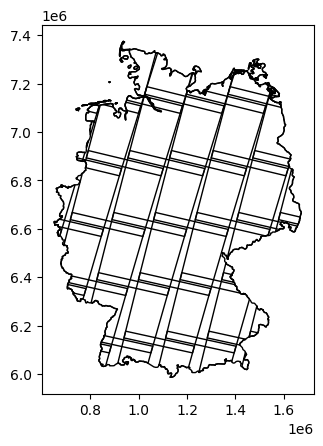

In [11]:
overlap.plot(edgecolor='black', facecolor='none')

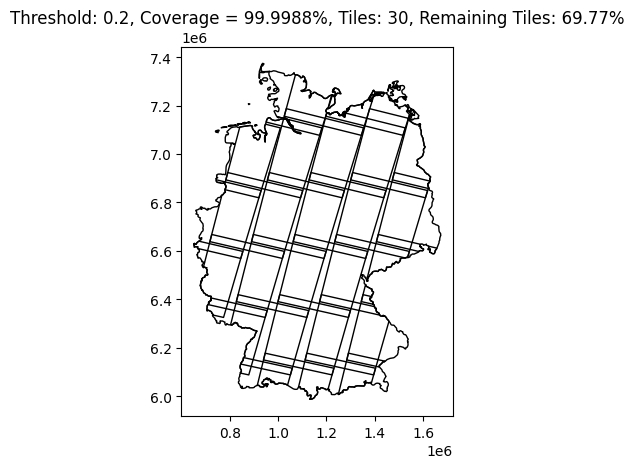

In [12]:
from shapely.ops import unary_union

percentage_threshold = 0.2


original_tile_count = int(overlap.shape[0])

data = overlap[overlap["remaining_area"] > percentage_threshold]

remaining_tiles = int(data.shape[0])

covering_tiles_union = unary_union(data.geometry)

coverage_percentage = covering_tiles_union.area / german_mask.area

ax = data.plot(edgecolor='black', facecolor='none')


title = f'Threshold: {percentage_threshold}, Coverage = {float(coverage_percentage[0]):.4%}, Tiles: {remaining_tiles}, Remaining Tiles: {remaining_tiles / original_tile_count:.2%}'

ax.set_title(title)

plt.show()

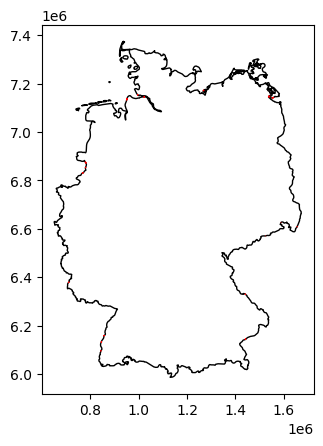

In [13]:

ax = german_mask.plot(edgecolor='black', facecolor='none')

gpd.overlay(data, german_mask, how="difference").plot(edgecolor='red', facecolor='red', ax=ax)

plt.show()

In [14]:
data[["WRS_PATH", "WRS_ROW", "remaining_area", "geometry"]].to_file("relevant_tiles.gpkg")